## 1. What this notebook computes

The quantities of this book depend on several variables at once: the author's
metric depends on the time $x_4$ and on the hidden coordinate $x_8$. This
notebook teaches how to differentiate such functions and checks every step. It

- computes the partial derivatives of $f(x, y) = x^2 \sin y$ with sympy, checks
  that the two mixed second derivatives agree, and draws the level curves of $f$
  with its gradient arrows and two slices with their tangent lines;
- approximates partial derivatives by finite differences and measures their
  orders (1 for the forward difference, 2 for the central one) and the limit
  that rounding errors set;
- checks the chain rule for the author's variable $z = 6 H x_8$;
- reads the author's metric from the Revision record
  Revision/gkd_lovelock/results/curvature.json and computes its partial
  derivatives: the growth rates of the eight scale factors along $x_4$ and along
  $x_8$, the volume factor $\sqrt{|\det g|} = \cos z$ (which does not depend on
  $x_4$), Jacobi's formula for the derivative of a determinant, and all 25
  nonzero *Christoffel symbols* listed in the record (combinations of first
  partial derivatives of the metric that the geometry of the book uses).

It draws 6 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 02c (Partial derivatives, finite differences and the chain rule) is the file
`Revision/textbook/notebooks/02c_partial_derivatives.ipynb` of the repository
Dirac_claude. It computes partial derivatives of a function of two variables with sympy
and by finite differences (forward and central differences, their orders 1 and 2 and the
limit set by rounding), draws level curves with the gradient and slices with their
tangent lines, checks that mixed partial derivatives do not depend on the order, checks
the chain rule for the author's variable z = 6 H x8, and then reads the author's metric
from a Revision record and computes its partial derivatives: the growth and deflation
rates of the eight scale factors, the volume factor sqrt of the absolute determinant
(equal to cos z and independent of the time x4), Jacobi's formula, and all 25 nonzero
Christoffel entries listed in the record. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 02c_partial_derivatives.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 02c_partial_derivatives.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
02c_partial_derivatives.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/02c.captions.json`
- `Revision/textbook/figures/02c_1_level_curves_gradient.png`
- `Revision/textbook/figures/02c_2_slices_and_slopes.png`
- `Revision/textbook/figures/02c_3_finite_differences.png`
- `Revision/textbook/figures/02c_4_chain_rule.png`
- `Revision/textbook/figures/02c_5_rates_along_x4.png`
- `Revision/textbook/figures/02c_6_rates_along_x8.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of notebook 02c exist
    ALL 17 CHECKS PASSED (notebook 02c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/02c_partial_derivatives.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 02c_partial_derivatives.ipynb
      python -m nbconvert --execute --inplace 02c_partial_derivatives.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 02c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 02c (Partial derivatives, finite differences and the chain rule) is the file
# Revision/textbook/notebooks/02c_partial_derivatives.ipynb of the repository
# Dirac_claude. It computes partial derivatives of a function of two variables with sympy
# and by finite differences (forward and central differences, their orders 1 and 2 and
# the limit set by rounding), draws level curves with the gradient and slices with their
# tangent lines, checks that mixed partial derivatives do not depend on the order, checks
# the chain rule for the author's variable z = 6 H x8, and then reads the author's metric
# from a Revision record and computes its partial derivatives: the growth and deflation
# rates of the eight scale factors, the volume factor sqrt of the absolute determinant
# (equal to cos z and independent of the time x4), Jacobi's formula, and all 25 nonzero
# Christoffel entries listed in the record. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 02c_partial_derivatives.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 02c_partial_derivatives.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 02c_partial_derivatives.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/02c.captions.json
# - Revision/textbook/figures/02c_1_level_curves_gradient.png
# - Revision/textbook/figures/02c_2_slices_and_slopes.png
# - Revision/textbook/figures/02c_3_finite_differences.png
# - Revision/textbook/figures/02c_4_chain_rule.png
# - Revision/textbook/figures/02c_5_rates_along_x4.png
# - Revision/textbook/figures/02c_6_rates_along_x8.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of notebook 02c exist
#     ALL 17 CHECKS PASSED (notebook 02c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/02c_partial_derivatives.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 02c_partial_derivatives.ipynb
#     python -m nbconvert --execute --inplace 02c_partial_derivatives.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "02c"  # this notebook: chapter 02, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 02c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Function of several variables**: a rule $f(x, y)$ that gives a number for
  every pair of numbers $(x, y)$ (or for every list $x_1, \dots, x_8$).
- **Partial derivative** $\partial f/\partial x$: the ordinary derivative with
  respect to $x$ while all the other variables are held fixed. We also write
  $\partial_x f$, and for the author's coordinates $\partial_4 = \partial/\partial
  x_4$ and $\partial_8 = \partial/\partial x_8$.
- **Slice**: the function of ONE variable obtained by holding the others fixed;
  the partial derivative is the slope of its graph.
- **Level curve (contour)**: the set of points where $f$ has one fixed value.
- **Gradient**: the arrow $(\partial f/\partial x, \partial f/\partial y)$. It
  points in the direction in which $f$ grows fastest and is perpendicular to the
  level curve through its point.
- **Mixed partial derivative**: $\partial^2 f/\partial x \partial y$, first with
  respect to $y$, then $x$ (or the other way round). Schwarz's theorem: for a
  function with continuous second derivatives the order does not matter.
- **Chain rule**: if $f$ depends on $z$ and $z$ on $x_8$, then
  $\partial f/\partial x_8 = (df/dz)(\partial z/\partial x_8)$.
- **Finite difference**: an approximation of a derivative from values of the
  function at nearby points, with a small spacing $h$.
- **Metric, diagonal entries** $g_{aa}$: the eight numbers (functions of $x_4$ and
  $x_8$) that turn coordinate distances into true distances in the author's
  8-dimensional world; positive for the space directions $x_1, x_2, x_3, x_8$ and
  negative for the time directions $x_4, x_5, x_6, x_7$.
- **Scale factor** $s_a = \sqrt{|g_{aa}|}$: the factor by which a coordinate
  length along $x_a$ is multiplied to give a true length.
- **Logarithmic derivative** $\partial \ln s/\partial x = (\partial s/\partial
  x)/s$: the rate of growth of $s$ per unit of $x$, as a fraction of $s$
  itself.
- **Determinant of a diagonal matrix**: the product of its diagonal entries.
- **Christoffel symbols** $\Gamma^a{}_{bc}$: numbers built from first partial
  derivatives of the metric; the geometry of the book explains their meaning.
  Here they are only an exercise in partial derivatives.

## 4. The physical and mathematical situation

**Definition.** For a function $f(x, y)$,

$$\frac{\partial f}{\partial x}(x, y) = \lim_{h \to 0}
\frac{f(x + h, y) - f(x, y)}{h},$$

the derivative of the slice $x \mapsto f(x, y)$ with $y$ held fixed; likewise for
$y$. All the rules of one-variable calculus hold for each partial derivative.

**The first example.** $f(x, y) = x^2 \sin y$. Holding $y$ fixed, $\sin y$ is a
constant factor and $\partial f/\partial x = 2x \sin y$. Holding $x$ fixed,
$x^2$ is a constant factor and $\partial f/\partial y = x^2 \cos y$. Then
$\partial/\partial y$ of $2x \sin y$ is $2x \cos y$ and $\partial/\partial x$ of
$x^2 \cos y$ is also $2x \cos y$: the mixed derivatives agree, as Schwarz's
theorem says.

**Finite differences.** Taylor's theorem in one variable gives
$f(x + h) = f(x) + h f'(x) + \frac{h^2}{2} f''(x) + \frac{h^3}{6} f'''(x) +
\dots$ Therefore the *forward difference* $(f(x + h) - f(x))/h = f'(x) +
\frac{h}{2} f''(x) + \dots$ has an error proportional to $h$ (order 1), and the
*central difference* $(f(x + h) - f(x - h))/(2h) = f'(x) + \frac{h^2}{6}
f'''(x) + \dots$ has an error proportional to $h^2$ (order 2), because the
terms with $h^2 f''$ cancel in the difference. Rounding adds an error of about
$\epsilon |f| / h$ ($\epsilon = 2.2 \times 10^{-16}$), which GROWS as $h$
shrinks; the best $h$ balances the two.

**The author's metric** (coordinates $x_1, \dots, x_8$; $z = 6 H x_8$ with
$0 < z < \pi/2$; $a_4(x_4)$ a function of the time):

$$g_{11} = g_{22} = g_{33} = e^{2 a_4} \sin^{1/3} z, \quad g_{44} = -1, \quad
g_{55} = g_{66} = g_{77} = -e^{-2 a_4} \sin^{1/3} z, \quad g_{88} = \cot^2 z .$$

The scale factors are $e^{a_4} \sin^{1/6} z$ for 3-space ($x_1, x_2, x_3$),
$1$ for the time $x_4$, $e^{-a_4} \sin^{1/6} z$ for the three extra times
$x_5, x_6, x_7$ (they DEFLATE when $a_4$ grows) and $\cot z$ for the hidden
direction $x_8$. By the chain rule, $\partial_8 = (dz/dx_8)\, d/dz = 6H\, d/dz$
on a function of $z$. The logarithmic rates follow from $\ln(e^{a_4}
\sin^{1/6} z) = a_4 + \frac{1}{6} \ln \sin z$:

$$\partial_4 \ln s_{1,2,3} = a_4', \quad \partial_4 \ln s_{5,6,7} = -a_4', \quad
\partial_8 \ln s_{1,2,3} = \partial_8 \ln s_{5,6,7} = \tfrac{1}{6} \cdot 6H \cot z
= H \cot z,$$

and $\partial_8 \ln \cot z = 6H \cdot \frac{-1/\sin^2 z}{\cot z} =
-\frac{6H}{\sin z \cos z}$. The determinant of the diagonal metric is the
product of the entries; four of them are negative, so it is positive:
$\det g = (e^{2a_4})^3 (e^{-2a_4})^3 (\sin^{1/3} z)^6 \cot^2 z = \sin^2 z
\cot^2 z = \cos^2 z$ and $\sqrt{|\det g|} = \cos z$. The factors $e^{6 a_4}$ and
$e^{-6 a_4}$ cancel: the inflation of 3-space and the deflation of the extra
times compensate, and the volume factor does not depend on $x_4$.

**Christoffel symbols of a diagonal metric.** We take the formula
$\Gamma^a{}_{bc} = \frac{1}{2 g_{aa}} (\partial_b g_{ac} + \partial_c g_{ab} -
\partial_a g_{bc})$ (no sum over $a$) as given; the geometry of the book
derives it. For a diagonal metric only two kinds of entry can be nonzero:
$\Gamma^a{}_{ac} = \partial_c g_{aa}/(2 g_{aa}) = \partial_c \ln s_a$, the
logarithmic rates above, and $\Gamma^c{}_{aa} = -\partial_c g_{aa}/(2 g_{cc})$
for $c \neq a$.

## 5. The set-up of this notebook

The next cell imports the packages, chooses the colours of the plots and
defines the sympy symbols $x$, $y$ of the first example.

In [2]:
import math  # functions of single numbers

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra and calculus with symbols

BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
GREY, BLACK = "#8a8986", "#000000"
x, y = sp.symbols("x y", real=True)  # the two variables of the first example
say("Packages imported; symbols x and y defined.")

Packages imported; symbols x and y defined.


## 6. Partial derivatives with sympy

`sp.diff(f, x)` differentiates with respect to $x$ and treats every other
symbol as a constant: exactly the definition of a partial derivative. The cell
prints the two first derivatives and the two mixed second derivatives of
$f = x^2 \sin y$, checks them against the hand calculation of section 4, and
evaluates everything at the point $(x_0, y_0) = (1.2, 0.7)$.

In [3]:
f = x ** 2 * sp.sin(y)
f_x = sp.diff(f, x)  # hold y fixed
f_y = sp.diff(f, y)  # hold x fixed
f_xy = sp.diff(f, x, y)  # first x, then y
f_yx = sp.diff(f, y, x)  # first y, then x
say(f"df/dx = {f_x},  df/dy = {f_y}")
say(f"d2f/dxdy = {f_xy},  d2f/dydx = {f_yx}")
check(sp.simplify(f_x - 2 * x * sp.sin(y)) == 0
      and sp.simplify(f_y - x ** 2 * sp.cos(y)) == 0,
      "df/dx = 2 x sin y and df/dy = x^2 cos y")
check(sp.simplify(f_xy - f_yx) == 0 and sp.simplify(f_xy - 2 * x * sp.cos(y)) == 0,
      "the mixed derivatives agree (Schwarz): both are 2 x cos y")
X0, Y0 = 1.2, 0.7  # the point at which we evaluate
at_point = {x: X0, y: Y0}
for label, expression in (("f", f), ("df/dx", f_x), ("df/dy", f_y),
                          ("d2f/dxdy", f_xy)):
    report(f"{label} at (1.2, 0.7)", f"{float(expression.subs(at_point)):.12f}")

df/dx = 2*x*sin(y),  df/dy = x**2*cos(y)
d2f/dxdy = 2*x*cos(y),  d2f/dydx = 2*x*cos(y)
PASS df/dx = 2 x sin y and df/dy = x^2 cos y
PASS the mixed derivatives agree (Schwarz): both are 2 x cos y
RESULT f at (1.2, 0.7) = 0.927673469622
RESULT df/dx at (1.2, 0.7) = 1.546122449370
RESULT df/dy at (1.2, 0.7) = 1.101372749690
RESULT d2f/dxdy at (1.2, 0.7) = 1.835621249483


## 7. Pictures of a function of two variables

The first figure is a map of $f$: coloured bands between level curves, and at
the points of a coarse grid the gradient arrow $(\partial f/\partial x,
\partial f/\partial y)$. `sp.lambdify` turns a sympy expression into a fast
numpy function. The check confirms at one point that the gradient is
perpendicular to the level curve: the direction along the level curve,
$(-\partial f/\partial y, \partial f/\partial x)$, has zero dot product with the
gradient, and moving a small step along it changes $f$ only in second order.
A second check confirms that the gradient points uphill: a small step of length
$10^{-4}$ along the unit arrow $\nabla f/|\nabla f|$, where
$|\nabla f| = \sqrt{(\partial f/\partial x)^2 + (\partial f/\partial y)^2}$ is
the length of the gradient, raises $f$ by about $10^{-4}\,|\nabla f|$ (the
steepest slope), and such a step raises $f$ at every one of the 120 arrows of
the figure.

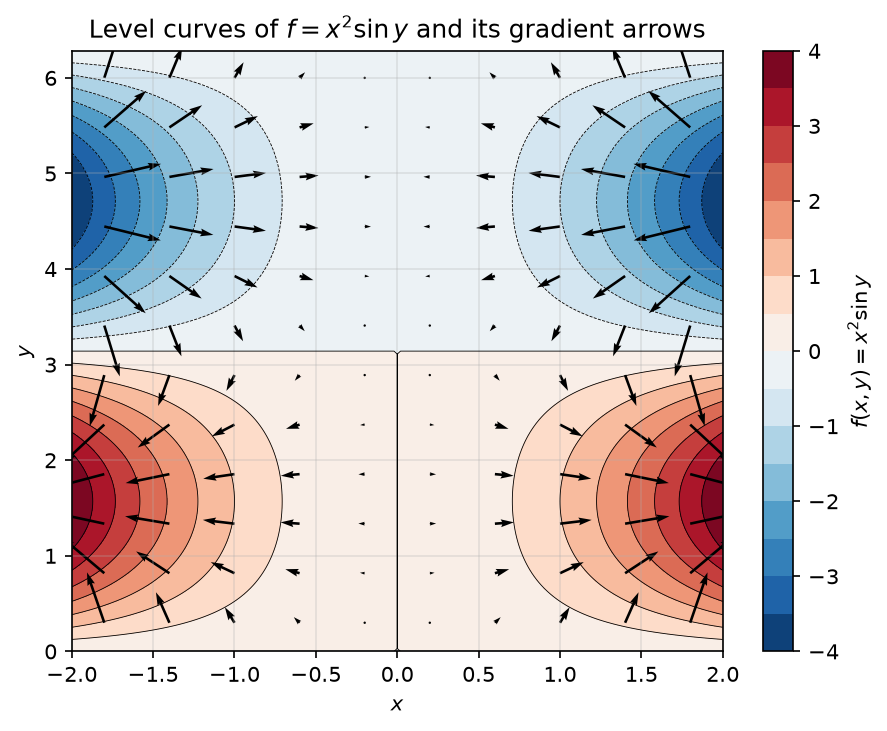

Figure 02c.1 saved as Revision/textbook/figures/02c_1_level_curves_gradient.png
RESULT change of f along the level curve for a step of 1e-4 = -9.58e-09
PASS the gradient is perpendicular to the level curve
RESULT rise of f per unit length along the gradient, |grad f| = 1.898407, 1.898293
PASS the gradient points uphill: f rises at the rate |grad f| along it


In [4]:
F = sp.lambdify((x, y), f, "numpy")  # f as a numpy function
FX = sp.lambdify((x, y), f_x, "numpy")
FY = sp.lambdify((x, y), f_y, "numpy")
xs = np.linspace(-2.0, 2.0, 201)
ys = np.linspace(0.0, 2.0 * np.pi, 201)
XX, YY = np.meshgrid(xs, ys)  # all grid points as two 2-dimensional arrays
fig, ax = plt.subplots(figsize=(7.0, 5.2))
bands = ax.contourf(XX, YY, F(XX, YY), levels=17, cmap="RdBu_r")  # coloured bands
ax.contour(XX, YY, F(XX, YY), levels=17, colors=BLACK, linewidths=0.4)
fig.colorbar(bands, ax=ax, label="$f(x, y) = x^2 \\sin y$")
xq, yq = np.meshgrid(np.linspace(-1.8, 1.8, 10), np.linspace(0.3, 6.0, 12))  # coarse
# an arrow (df/dx, df/dy) at every coarse grid point; scale=40 shortens all arrows
ax.quiver(xq, yq, FX(xq, yq), FY(xq, yq), color=BLACK, scale=40, width=0.004)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Level curves of $f = x^2 \\sin y$ and its gradient arrows")
save_figure(fig, "level_curves_gradient",
            "A map of the function $f(x, y) = x^2 \\sin y$ for $x$ from $-2$ to $2$ "
            "(horizontal axis) and $y$ from $0$ to $2\\pi$ (vertical axis); all "
            "quantities are pure numbers. The colour shows the value of $f$ (red "
            "positive, blue negative), the thin black lines are level curves, and "
            "the arrows are the gradient $(\\partial f/\\partial x, \\partial "
            "f/\\partial y)$ at a grid of points. Every arrow points uphill and "
            "crosses the level curves at a right angle; long arrows mean a steep "
            "slope.")
gx, gy = float(f_x.subs(at_point)), float(f_y.subs(at_point))
tangent = np.array([-gy, gx]) / math.hypot(gx, gy)  # along the level curve
step = 1e-4
change = F(X0 + step * tangent[0], Y0 + step * tangent[1]) - F(X0, Y0)
report("change of f along the level curve for a step of 1e-4", f"{change:.2e}")
check(abs(gx * tangent[0] + gy * tangent[1]) < 1e-15 and abs(change) < 1e-7,
      "the gradient is perpendicular to the level curve")

length = math.hypot(gx, gy)  # the length |grad f| of the gradient arrow
rise = F(X0 + step * gx / length, Y0 + step * gy / length) - F(X0, Y0)
report("rise of f per unit length along the gradient, |grad f|",
       f"{rise / step:.6f}, {length:.6f}")
gxq, gyq = FX(xq, yq), FY(xq, yq)  # the arrows of the figure
lengths = np.hypot(gxq, gyq)
rises = F(xq + step * gxq / lengths, yq + step * gyq / lengths) - F(xq, yq)
check(abs(rise / step / length - 1) < 1e-3 and np.all(rises > 0),
      "the gradient points uphill: f rises at the rate |grad f| along it")

The second figure shows what a partial derivative IS: the slope of a slice. On
the left, $y = y_0 = 0.7$ is held fixed and $f$ is drawn as a function of $x$; on
the right, $x = x_0 = 1.2$ is held fixed and $f$ is drawn as a function of $y$.
The dashed lines through the point have the slopes $\partial f/\partial x$ and
$\partial f/\partial y$ at $(x_0, y_0)$: they are the tangent lines of the
slices.

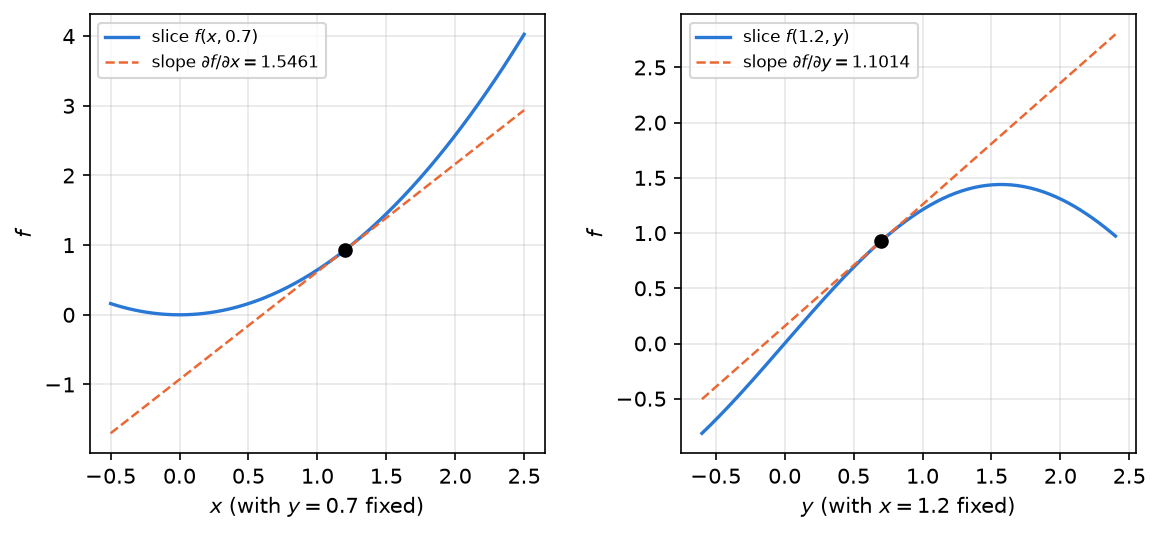

Figure 02c.2 saved as Revision/textbook/figures/02c_2_slices_and_slopes.png
PASS the slopes of the slices are 2 x0 sin y0 and x0^2 cos y0


In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
fig.subplots_adjust(wspace=0.3)  # room between the two panels
f0 = F(X0, Y0)
x_line = np.linspace(-0.5, 2.5, 200)
left.plot(x_line, F(x_line, Y0), color=BLUE, lw=1.6,
          label="slice $f(x, 0.7)$")
left.plot(x_line, f0 + gx * (x_line - X0), "--", color=ORANGE, lw=1.2,
          label=f"slope $\\partial f/\\partial x = {gx:.4f}$")
left.set_xlabel("$x$ (with $y = 0.7$ fixed)")
y_line = np.linspace(-0.6, 2.4, 200)
right.plot(y_line, F(X0, y_line), color=BLUE, lw=1.6, label="slice $f(1.2, y)$")
right.plot(y_line, f0 + gy * (y_line - Y0), "--", color=ORANGE, lw=1.2,
           label=f"slope $\\partial f/\\partial y = {gy:.4f}$")
right.set_xlabel("$y$ (with $x = 1.2$ fixed)")
for ax in (left, right):
    ax.plot([X0 if ax is left else Y0], [f0], "o", color=BLACK, ms=6)
    ax.set_ylabel("$f$")
    ax.legend(fontsize=8)
save_figure(fig, "slices_and_slopes",
            "Two slices of $f(x, y) = x^2 \\sin y$ through the point "
            "$(x_0, y_0) = (1.2, 0.7)$ (black dot); all quantities are pure "
            "numbers. Left: $f$ as a function of $x$ with $y = 0.7$ held fixed, "
            "and its tangent line (dashed) of slope $\\partial f/\\partial x = "
            "2 x_0 \\sin y_0 = 1.5461$. Right: $f$ as a function of $y$ with "
            "$x = 1.2$ held fixed, and its tangent line of slope $\\partial "
            "f/\\partial y = x_0^2 \\cos y_0 = 1.1014$. A partial derivative is "
            "the slope of a slice.")
check(abs(gx - 2 * X0 * math.sin(Y0)) < 1e-15 and abs(gy - X0 ** 2 * math.cos(Y0))
      < 1e-15, "the slopes of the slices are 2 x0 sin y0 and x0^2 cos y0")

## 8. Finite differences: order and rounding

The next cell approximates three derivatives at $(1.2, 0.7)$ for 49 spacings
$h$ from $10^{-12}$ to $1$ (equally spaced in $\log h$):

- forward difference for $\partial f/\partial y$: $(f(x_0, y_0 + h) -
  f(x_0, y_0))/h$;
- central difference for $\partial f/\partial y$: $(f(x_0, y_0 + h) -
  f(x_0, y_0 - h))/(2h)$;
- central difference for the mixed derivative $\partial^2 f/\partial x \partial
  y$: $[f(x_0{+}h, y_0{+}h) - f(x_0{+}h, y_0{-}h) - f(x_0{-}h, y_0{+}h) +
  f(x_0{-}h, y_0{-}h)]/(4h^2)$.

It fits the slopes on the log-log plot where truncation dominates, and finds the
best $h$ of each formula, where truncation and rounding balance.

RESULT forward: slope 1.000, best h = 1.0e-08 (error 1.1e-09)
RESULT central: slope 2.000, best h = 1.8e-06 (error 5.3e-12)
RESULT mixed: slope 2.000, best h = 5.6e-05 (error 1.4e-09)


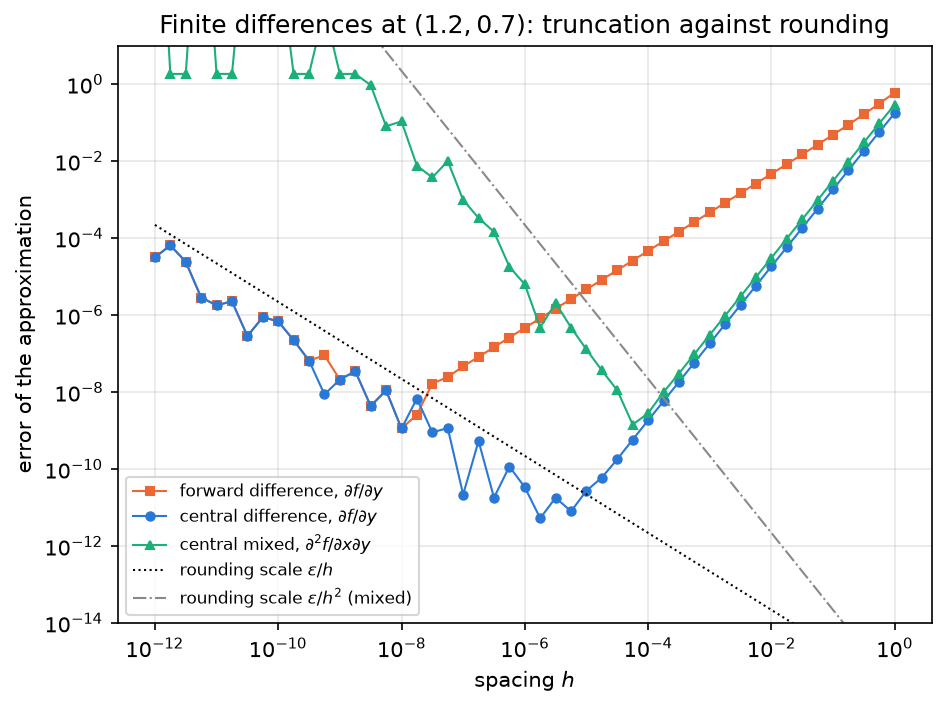

Figure 02c.3 saved as Revision/textbook/figures/02c_3_finite_differences.png
PASS measured orders: forward 1, central 2, mixed central 2
PASS best central error < 1e-10 < best forward error < 1e-7


In [6]:
exact_y = X0 ** 2 * math.cos(Y0)  # df/dy at the point
exact_xy = 2 * X0 * math.cos(Y0)  # d2f/dxdy at the point
h_values = np.logspace(-12, 0, 49)  # 1e-12 ... 1
forward = np.array([(F(X0, Y0 + h) - F(X0, Y0)) / h for h in h_values])
central = np.array([(F(X0, Y0 + h) - F(X0, Y0 - h)) / (2 * h) for h in h_values])
mixed = np.array([(F(X0 + h, Y0 + h) - F(X0 + h, Y0 - h) - F(X0 - h, Y0 + h)
                   + F(X0 - h, Y0 - h)) / (4 * h * h) for h in h_values])
err = {"forward": np.abs(forward - exact_y), "central": np.abs(central - exact_y),
       "mixed": np.abs(mixed - exact_xy)}
RANGES = {"forward": (1e-5, 1e-2), "central": (1e-3, 1e-1), "mixed": (1e-2, 1e-1)}
slope_of = {}
for name, (low, high) in RANGES.items():
    part = (h_values >= low) & (h_values <= high)
    slope_of[name], _ = np.polyfit(np.log10(h_values[part]),
                                   np.log10(err[name][part]), 1)
    best = int(np.argmin(err[name]))
    report(f"{name}: slope {slope_of[name]:.3f}, best h", f"{h_values[best]:.1e} "
           f"(error {err[name][best]:.1e})")
fig, ax = plt.subplots(figsize=(7.0, 5.0))
styles = {"forward": (ORANGE, "s", "forward difference, $\\partial f/\\partial y$"),
          "central": (BLUE, "o", "central difference, $\\partial f/\\partial y$"),
          "mixed": (AQUA, "^", "central mixed, $\\partial^2 f/\\partial x "
                               "\\partial y$")}
for name, (color, marker, label) in styles.items():
    shown = err[name] > 0  # an exact zero cannot be drawn on a log axis
    ax.loglog(h_values[shown], err[name][shown], marker=marker, color=color, ms=4,
              lw=1.0, label=label)
ax.loglog(h_values, 2.2e-16 / h_values, ":", color=BLACK, lw=1.0,
          label="rounding scale $\\epsilon / h$")
ax.loglog(h_values, 2.2e-16 / h_values ** 2, "-.", color=GREY, lw=1.0,
          label="rounding scale $\\epsilon / h^2$ (mixed)")
ax.set_ylim(1e-14, 10.0)
ax.set_xlabel("spacing $h$")
ax.set_ylabel("error of the approximation")
ax.set_title("Finite differences at $(1.2, 0.7)$: truncation against rounding")
ax.legend(loc="lower left", fontsize=8)
save_figure(fig, "finite_differences",
            "The error of three finite-difference approximations at the point "
            "$(1.2, 0.7)$ against the spacing $h$ from $10^{-12}$ to $1$, on "
            "logarithmic axes (pure numbers): forward difference for "
            "$\\partial f/\\partial y$ (squares), central difference for "
            "$\\partial f/\\partial y$ (circles) and the central formula for the "
            "mixed derivative (triangles), for $f = x^2 \\sin y$. Coming from the "
            "right, the errors fall with slope 1 (forward) and slope 2 (central, "
            "mixed). Coming from the left, rounding errors, of the size "
            "$\\epsilon / h$ (dotted) or $\\epsilon / h^2$ (dash-dotted) for the "
            "mixed formula, "
            "dominate. The best spacings are near $10^{-8}$, $10^{-6}$ and "
            "$10^{-4}$.")
check(abs(slope_of["forward"] - 1) < 0.05 and abs(slope_of["central"] - 2) < 0.05
      and abs(slope_of["mixed"] - 2) < 0.05,
      "measured orders: forward 1, central 2, mixed central 2")
check(err["central"].min() < 1e-10 < err["forward"].min() < 1e-7,
      "best central error < 1e-10 < best forward error < 1e-7")

## 9. The chain rule with $z = 6 H x_8$

The author writes the hidden direction with $z = 6 H x_8$. A function of $z$,
such as $g_{88} = \cot^2 z$, depends on $x_8$ through $z$, and the chain rule
says $\partial_8 \cot^2(6 H x_8) = 6H \cdot \frac{d}{dz} \cot^2 z$. The cell
checks it with sympy, and the figure shows it with $H = 1$: the same curve
drawn against $z$ and against $x_8 = z/6$ is squeezed sideways by the factor 6,
so every slope is 6 times steeper.

d/dx8 cot(6 H x8)^2 = -12*H*cot(6*H*x8)/sin(6*H*x8)**2
PASS chain rule: d/dx8 of cot(6 H x8)^2 = 6 H times d/dz of cot(z)^2


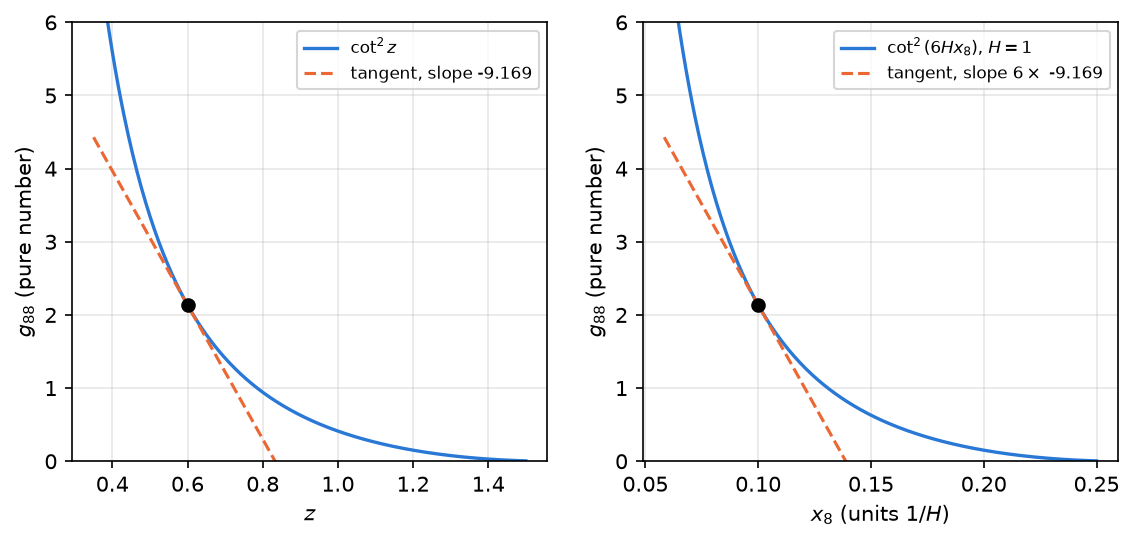

Figure 02c.4 saved as Revision/textbook/figures/02c_4_chain_rule.png


In [7]:
x4, x8 = sp.symbols("x4 x8", real=True)  # the time and the hidden coordinate
H = sp.symbols("H", positive=True)  # the author's constant H > 0
zs = sp.symbols("z", positive=True)  # z = 6 H x8 as a symbol of its own
through_x8 = sp.diff(sp.cot(6 * H * x8) ** 2, x8)  # differentiate in x8 directly
through_z = 6 * H * sp.diff(sp.cot(zs) ** 2, zs).subs(zs, 6 * H * x8)  # chain rule
say(f"d/dx8 cot(6 H x8)^2 = {sp.simplify(through_x8)}")
check(sp.simplify(through_x8 - through_z) == 0,
      "chain rule: d/dx8 of cot(6 H x8)^2 = 6 H times d/dz of cot(z)^2")

z0 = 0.6  # the point z0 and the matching x8 = z0/6 (H = 1)
slope_z = -2.0 * math.cos(z0) / math.sin(z0) ** 3  # d/dz cot^2 z = -2 cot z / sin^2 z
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
z_line = np.linspace(0.35, 1.5, 300)
left.plot(z_line, 1 / np.tan(z_line) ** 2, color=BLUE, lw=1.6,
          label="$\\cot^2 z$")
left.plot(z_line, 1 / math.tan(z0) ** 2 + slope_z * (z_line - z0), "--",
          color=ORANGE, label=f"tangent, slope {slope_z:.3f}")
left.set_xlabel("$z$")
x8_line = z_line / 6.0
right.plot(x8_line, 1 / np.tan(6 * x8_line) ** 2, color=BLUE, lw=1.6,
           label="$\\cot^2(6 H x_8)$, $H = 1$")
right.plot(x8_line, 1 / math.tan(z0) ** 2 + 6 * slope_z * (x8_line - z0 / 6), "--",
           color=ORANGE, label=f"tangent, slope $6 \\times$ {slope_z:.3f}")
right.set_xlabel("$x_8$ (units $1/H$)")
for ax, where in ((left, z0), (right, z0 / 6)):
    ax.plot([where], [1 / math.tan(z0) ** 2], "o", color=BLACK, ms=6)
    ax.set_ylim(0.0, 6.0)
    ax.set_ylabel("$g_{88}$ (pure number)")
    ax.legend(fontsize=8)
save_figure(fig, "chain_rule",
            "The chain rule for the author's hidden coordinate. Left: "
            "$g_{88} = \\cot^2 z$ against $z$ from 0.35 to 1.5, with its tangent "
            "line at $z = 0.6$. Right: the same function against $x_8 = z/(6H)$ "
            "with $H = 1$ ($x_8$ in units of $1/H$), with its tangent line at "
            "$x_8 = 0.1$. Both vertical axes show $g_{88}$, a pure number. The "
            "right curve is the left one squeezed sideways by the factor 6, so "
            "its slope is 6 times steeper: $\\partial_8 = 6H\\, d/dz$.")

## 10. The author's metric, read from the Revision record

The Rust program of the Revision record that computed the curvature of the
author's metric stored the metric's diagonal in the file
Revision/gkd_lovelock/results/curvature.json, written in the notation of the
Wolfram Language (`E^(...)` is $e^{\dots}$, `Sin[...]` is $\sin(\dots)$,
`Derivative[1][a4][x4]` is $a_4'$). The function `from_record` translates such a
text into a sympy expression: square brackets become round ones and `^` becomes
`**`. The cell compares the eight entries with the formulas of section 4,
typed in by hand.

In [8]:
CURVATURE = "Revision/gkd_lovelock/results/curvature.json"
record = json.loads(repository_file(CURVATURE).read_text(encoding="utf-8"))
a4 = sp.Function("a4")  # the unknown function a4(x4) of the metric
NAMES = {"a4": a4, "x4": x4, "x8": x8, "H": H, "Sin": sp.sin, "Cos": sp.cos,
         "Cot": sp.cot}


def from_record(text):
    """A Wolfram-Language text of the record as a sympy expression."""
    text = text.replace("Derivative[1][a4][x4]", "Derivative(a4(x4), x4)")
    text = text.replace("[", "(").replace("]", ")").replace("^", "**")
    return sp.parse_expr(text, local_dict=NAMES)


def tidy(expression):
    """Write cot and tan as quotients of cos and sin (helps sympy simplify)."""
    expression = expression.replace(sp.cot, lambda u: sp.cos(u) / sp.sin(u))
    return expression.replace(sp.tan, lambda u: sp.sin(u) / sp.cos(u))


def same(first, second):
    """True when sympy simplifies first - second to zero."""
    return sp.simplify(tidy(first - second)) == 0


COORDS = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
X = [sp.Symbol(name, real=True) for name in COORDS]
X[3], X[7] = x4, x8  # the metric depends on these two only
z = 6 * H * x8
third = sp.Rational(1, 3)
BY_HAND = ([sp.exp(2 * a4(x4)) * sp.sin(z) ** third] * 3 + [sp.Integer(-1)]
           + [-sp.exp(-2 * a4(x4)) * sp.sin(z) ** third] * 3 + [sp.cot(z) ** 2])
G_RECORD = [from_record(text) for text in record["metricDiagonal"]]
for name, entry in zip(COORDS, G_RECORD):
    say(f"g_{name[1]}{name[1]} = {entry}")
check(record["coordinates"] == COORDS
      and all(same(a, b) for a, b in zip(G_RECORD, BY_HAND)),
      "the record's metric equals the author's metric typed in by hand",
      record=f"{CURVATURE}, key metricDiagonal")
G = sp.diag(*G_RECORD)  # the metric as an 8 x 8 diagonal sympy matrix

g_11 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
g_22 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
g_33 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
g_44 = -1
g_55 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
g_66 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
g_77 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
g_88 = cot(6*H*x8)**2
PASS the record's metric equals the author's metric typed in by hand
     reproduces Revision/gkd_lovelock/results/curvature.json, key metricDiagonal


## 11. How fast the scale factors change: rates along $x_4$ and $x_8$

The next cell computes the logarithmic rates $\partial_c \ln s_a =
\partial_c g_{aa}/(2 g_{aa})$ of the eight scale factors with respect to $x_4$
and $x_8$ and checks the formulas of section 4. It then evaluates them along the
linear history $a_4 = A H x_4$ with $A = 1$ and $H = 1$ (so $a_4' = 1$), the
prescribed background that the book uses for its Kohn-Sham states: the bar
chart shows the rates along $x_4$, $+1$ for the three 3-space directions
(inflation), $-1$ for the three extra times (deflation) and $0$ for $x_4$ and
$x_8$. Their sum is zero, which is why the volume does not change with time.
sympy prints $H \cot z$ as `H/tan(6*H*x8)` and $-6H/(\sin z \cos z)$ as
`-12*H/sin(12*H*x8)`; these are the same, because $\sin 2z = 2 \sin z \cos z$.

x1: d4 ln s = Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x2: d4 ln s = Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x3: d4 ln s = Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x4: d4 ln s = 0,  d8 ln s = 0
x5: d4 ln s = -Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x6: d4 ln s = -Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x7: d4 ln s = -Derivative(a4(x4), x4),  d8 ln s = H/tan(6*H*x8)
x8: d4 ln s = 0,  d8 ln s = -12*H/sin(12*H*x8)
PASS the rates a4', -a4', H cot z and -6H/(sin z cos z) of section 4
PASS the eight rates along x4 add up to zero


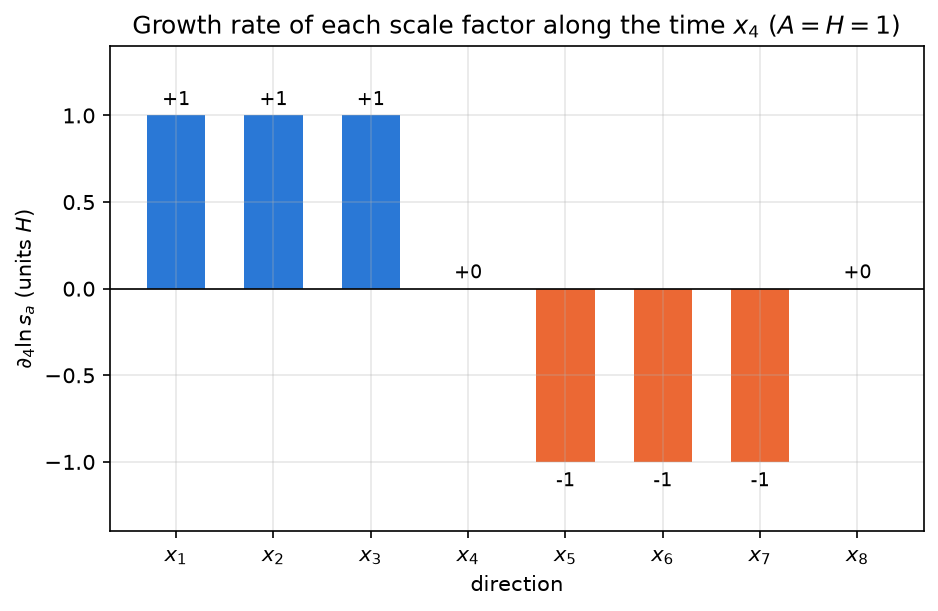

Figure 02c.5 saved as Revision/textbook/figures/02c_5_rates_along_x4.png


In [9]:
rate4 = [sp.simplify(sp.diff(G[a, a], x4) / (2 * G[a, a])) for a in range(8)]
rate8 = [sp.simplify(tidy(sp.diff(G[a, a], x8) / (2 * G[a, a]))) for a in range(8)]
da4 = sp.diff(a4(x4), x4)  # a4', the derivative of a4
expected4 = [da4] * 3 + [0] + [-da4] * 3 + [0]
expected8 = [H * sp.cot(z)] * 3 + [0] + [H * sp.cot(z)] * 3 + [-6 * H / (sp.sin(z)
                                                                      * sp.cos(z))]
for a, name in enumerate(COORDS):
    say(f"{name}: d4 ln s = {rate4[a]},  d8 ln s = {rate8[a]}")
check(all(same(r, e) for r, e in zip(rate4, expected4))
      and all(same(r, e) for r, e in zip(rate8, expected8)),
      "the rates a4', -a4', H cot z and -6H/(sin z cos z) of section 4")
check(sp.simplify(sum(rate4)) == 0, "the eight rates along x4 add up to zero")

rates_now = [float(r.subs(da4, 1)) for r in rate4]
fig, ax = plt.subplots()
colors = [BLUE] * 3 + [GREY] + [ORANGE] * 3 + [GREY]
ax.bar(range(8), rates_now, color=colors, width=0.6)
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.set_xticks(range(8), [f"$x_{k}$" for k in range(1, 9)])
for k, value in enumerate(rates_now):
    ax.text(k, value + (0.06 if value >= 0 else -0.14), f"{value:+.0f}",
            ha="center", fontsize=9)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel("direction")
ax.set_ylabel("$\\partial_4 \\ln s_a$ (units $H$)")
ax.set_title("Growth rate of each scale factor along the time $x_4$ ($A = H = 1$)")
save_figure(fig, "rates_along_x4",
            "The rate $\\partial_4 \\ln s_a$ at which the scale factor $s_a$ of "
            "each direction changes with the time $x_4$ (vertical axis, units of "
            "$H$), along the linear history $a_4 = A H x_4$ with $A = H = 1$. "
            "The three 3-space directions $x_1, x_2, x_3$ (blue) grow at the rate "
            "$+a_4' = +1$: 3-space inflates. The three extra times $x_5, x_6, x_7$ "
            "(orange) shrink at the rate $-a_4' = -1$: they deflate "
            "exponentially. The time $x_4$ and the hidden direction $x_8$ (grey) "
            "do not change with $x_4$. The eight rates add up to zero.")

The rates along the hidden coordinate depend on $z$. The next cell draws them
with $H = 1$ for $0.05 < z < \pi/2 - 0.05$: $H \cot z$ for the 3-space and
extra-time factors, $-6H/(\sin z \cos z)$ for the hidden factor $\cot z$, and
their sum over all eight directions, which must be the logarithmic rate of the
volume factor, $\partial_8 \ln \cos z = -6H \tan z$. The check confirms the sum
exactly with sympy.

PASS the eight rates along x8 add up to d8 ln cos z = -6 H tan z


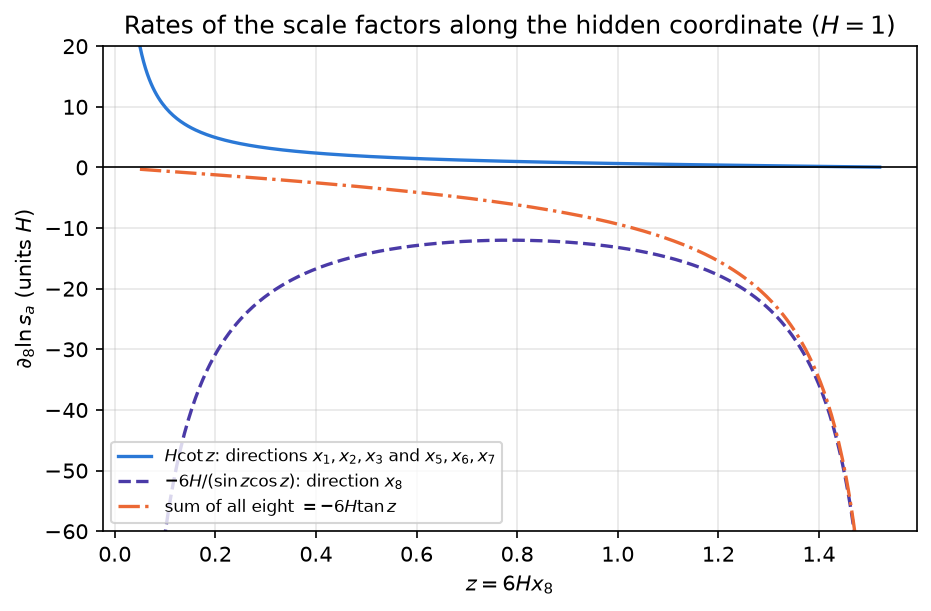

Figure 02c.6 saved as Revision/textbook/figures/02c_6_rates_along_x8.png


In [10]:
rate_sum8 = sp.simplify(tidy(sum(rate8)))
check(same(rate_sum8, -6 * H * sp.tan(z)),
      "the eight rates along x8 add up to d8 ln cos z = -6 H tan z")
z_line = np.linspace(0.05, np.pi / 2 - 0.05, 400)
fig, ax = plt.subplots()
ax.plot(z_line, 1 / np.tan(z_line), color=BLUE, lw=1.6,
        label="$H \\cot z$: directions $x_1, x_2, x_3$ and $x_5, x_6, x_7$")
ax.plot(z_line, -6 / (np.sin(z_line) * np.cos(z_line)), "--", color=VIOLET, lw=1.6,
        label="$-6H/(\\sin z \\cos z)$: direction $x_8$")
ax.plot(z_line, -6 * np.tan(z_line), "-.", color=ORANGE, lw=1.6,
        label="sum of all eight $= -6 H \\tan z$")
ax.axhline(0.0, color=BLACK, lw=0.8)
ax.set_ylim(-60.0, 20.0)
ax.set_xlabel("$z = 6 H x_8$")
ax.set_ylabel("$\\partial_8 \\ln s_a$ (units $H$)")
ax.set_title("Rates of the scale factors along the hidden coordinate ($H = 1$)")
ax.legend(loc="lower left", fontsize=8)
save_figure(fig, "rates_along_x8",
            "The rates $\\partial_8 \\ln s_a$ at which the scale factors change "
            "along the hidden coordinate $x_8$ (vertical axis, units of $H$, "
            "$H = 1$), against $z = 6 H x_8$ from 0.05 to $\\pi/2 - 0.05$. Solid "
            "blue: $H \\cot z$, the same for the three 3-space and the three "
            "extra-time directions. Dashed violet: $-6H/(\\sin z \\cos z)$ for "
            "the hidden direction, whose scale factor is $\\cot z$. Dash-dotted "
            "orange: the sum of all eight rates, which equals the rate "
            "$-6 H \\tan z$ of the volume factor $\\cos z$.")

## 12. The volume factor and Jacobi's formula

The determinant of the diagonal metric is the product of its entries. The cell
computes it from the record's metric, compares $\sqrt{|\det g|}$ with the
record's own entry `sqrtAbsDetG` ($\sin z \cot z$) and with $\cos z$ (the
Wolfram check `sqrt_abs_det_g_is_cos_z` of the Revision record
Revision/field_equations_a4/reports/wolfram-a4-report.json), and checks that
its partial derivative with respect to $x_4$ is zero: the volume factor does
not change with time, for EVERY function $a_4(x_4)$. Finally it checks
Jacobi's formula $\partial_c \sqrt{|\det g|} = \frac{1}{2} \sqrt{|\det g|}\,
\mathrm{tr}(g^{-1} \partial_c g)$ for $c = x_4$ and $c = x_8$ (tr, the trace,
is the sum of the diagonal entries of a matrix).

In [11]:
det_g = sp.simplify(tidy(G.det()))  # the product of the eight entries
say(f"det g = {det_g}")
sqrt_record = from_record(record["sqrtAbsDetG"])
say(f"sqrtAbsDetG of the record = {sqrt_record}")
check(same(det_g, sp.cos(z) ** 2) and same(sqrt_record, sp.cos(z)),
      "det g = cos(z)^2 and the record's sqrt|det g| = sin z cot z = cos z",
      record=f"{CURVATURE}, key sqrtAbsDetG")
A4REPORT = "Revision/field_equations_a4/reports/wolfram-a4-report.json"
a4_report = json.loads(repository_file(A4REPORT).read_text(encoding="utf-8"))
verdict = [c["verdict"] for c in a4_report["checks"]
           if c["name"] == "sqrt_abs_det_g_is_cos_z"]
check(verdict == ["PASS"] and sp.diff(sqrt_record, x4) == 0,
      "sqrt|det g| = cos z does not depend on x4 (inflation and deflation cancel)",
      record=f"{A4REPORT}, check sqrt_abs_det_g_is_cos_z")
jacobi = [same(sp.diff(sqrt_record, c),
               sp.Rational(1, 2) * sqrt_record * (G.inv() * G.diff(c)).trace())
          for c in (x4, x8)]
check(all(jacobi), "Jacobi's formula for the derivative of sqrt|det g| (x4 and x8)")

det g = cos(6*H*x8)**2
sqrtAbsDetG of the record = sin(6*H*x8)*cot(6*H*x8)
PASS det g = cos(z)^2 and the record's sqrt|det g| = sin z cot z = cos z
     reproduces Revision/gkd_lovelock/results/curvature.json, key sqrtAbsDetG
PASS sqrt|det g| = cos z does not depend on x4 (inflation and deflation cancel)
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    sqrt_abs_det_g_is_cos_z
PASS Jacobi's formula for the derivative of sqrt|det g| (x4 and x8)


## 13. All 25 Christoffel entries of the record

The record lists every nonzero $\Gamma^a{}_{bc}$ with $b$ not after $c$ in the
order $x_1, \dots, x_8$ (the symbol is symmetric in $b$ and $c$). The next cell
computes all $8 \times 36 = 288$ such entries from the formula of section 4,
keeps the nonzero ones, and compares them one by one with the record. Only
first partial derivatives of the metric entries are needed.

In [12]:
computed = {}
for a in range(8):
    for b in range(8):
        for c in range(b, 8):
            value = (sp.diff(G[a, c], X[b]) + sp.diff(G[a, b], X[c])
                     - sp.diff(G[b, c], X[a])) / (2 * G[a, a])
            value = sp.simplify(tidy(value))
            if value != 0:
                computed[(COORDS[a], COORDS[b], COORDS[c])] = value
listed = {(e["a"], e["b"], e["c"]): from_record(e["value"])
          for e in record["christoffelNonzero_b_le_c"]}
for key in [("x1", "x1", "x4"), ("x5", "x4", "x5"), ("x8", "x1", "x1"),
            ("x8", "x8", "x8")]:
    say(f"Gamma^{key[0]}_({key[1]} {key[2]}) = {computed[key]}")
report("nonzero entries computed / listed in the record",
       f"{len(computed)} / {len(listed)}")
check(sorted(computed) == sorted(listed)
      and all(same(computed[k], listed[k]) for k in listed),
      "all 25 nonzero Christoffel entries equal those of the record",
      record=f"{CURVATURE}, key christoffelNonzero_b_le_c")

Gamma^x1_(x1 x4) = Derivative(a4(x4), x4)
Gamma^x5_(x4 x5) = -Derivative(a4(x4), x4)
Gamma^x8_(x1 x1) = -H*exp(2*a4(x4))*sin(6*H*x8)**(4/3)/cos(6*H*x8)
Gamma^x8_(x8 x8) = -12*H/sin(12*H*x8)
RESULT nonzero entries computed / listed in the record = 25 / 25
PASS all 25 nonzero Christoffel entries equal those of the record
     reproduces Revision/gkd_lovelock/results/curvature.json, key
    christoffelNonzero_b_le_c


## 14. The last check

The last cell checks that all 6 figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
names = ["level_curves_gradient", "slices_and_slopes", "finite_differences",
         "chain_rule", "rates_along_x4", "rates_along_x8"]
present = [output_file(f"{FIGURE_FOLDER}/02c_{k}_{name}.png").is_file()
           for k, name in enumerate(names, 1)]
check(all(present), f"all {len(names)} figure files of notebook 02c exist")
all_checks_passed()

PASS all 6 figure files of notebook 02c exist
ALL 17 CHECKS PASSED (notebook 02c)


## 15. What this notebook showed

- A partial derivative is an ordinary derivative with the other variables held
  fixed: the slope of a slice. The gradient points uphill, perpendicular to the
  level curves. The two mixed derivatives of $x^2 \sin y$ agree (Schwarz).
- Forward differences have order 1, central differences order 2; rounding
  errors grow like $\epsilon/h$, so the best spacing is about $10^{-8}$
  (forward) or $10^{-6}$ (central), not the smallest one.
- The chain rule for $z = 6 H x_8$: $\partial_8 = 6H\, d/dz$.
- The author's metric, read from the Revision record, has the scale-factor rates
  $+a_4'$ (3-space, inflating), $-a_4'$ (the three extra times, deflating),
  $0$ (the time $x_4$ and the hidden $x_8$) along $x_4$, and $H \cot z$,
  $H \cot z$ and $-6H/(\sin z \cos z)$ along $x_8$.
- $\sqrt{|\det g|} = \sin z \cot z = \cos z$ for every $a_4(x_4)$: the
  inflation of 3-space and the deflation of the extra times cancel in the
  volume (reproduces the record's sqrtAbsDetG and the Wolfram check
  sqrt_abs_det_g_is_cos_z). Jacobi's formula holds.
- All 25 nonzero Christoffel entries of the record follow from first partial
  derivatives of the metric.